In [3]:
# Imports
import jax
import jax.random as jr
import jax.numpy as jnp
import matplotlib.pyplot as plt
from diffrax import diffeqsolve, ControlTerm, Euler, Heun, Midpoint, MultiTerm, ODETerm, SaveAt, VirtualBrownianTree, UnsafeBrownianPath

In [100]:
# Global parameters, create brownian path(s)
t0, t1 = 0, 2
epsilon = 0.0001
lag = 100*epsilon
times = jnp.arange(t0, t1, epsilon)

In [101]:

def fun_to_array(grid, fun):
    return jax.vmap(lambda t: fun(t))(grid)
new_times = jnp.arange(1, 2, epsilon)

def lagged_control(fun, lag):
    return lambda s,t: fun(jnp.maximum(0,t - lag/2)) - fun(jnp.maximum(0,s - lag/2))

def join_controls(lagged, original):
    return lambda s,t: jnp.concatenate((lagged(s,t), original(s,t)))




We want to approximate the solution to $\mathrm{d}Y_t = \sigma(Y_t,t) \mathrm{d} W_t$ as $\dot Y^{\varepsilon, +}$, where $$\begin{pmatrix} \dot Y^{\varepsilon, -}_t \\ \dot Y^{\varepsilon, +}_t \end{pmatrix} =  \sigma(Y^{\varepsilon, -}_t) \begin{pmatrix} \dot W^{\varepsilon, -}_t \\ \dot W^{\varepsilon, +}_t \end{pmatrix}.$$ Here $\varepsilon$ is the discretisation of the brownian motion; the solver should be on a much finer grid.

In [103]:
vbt = VirtualBrownianTree(t0, t1+2*epsilon, tol=epsilon, shape=(1,), key=jr.PRNGKey(505))
bm_control = vbt.evaluate
lagged_bm_control = lagged_control(bm_control, lag)
lead_lag_control = join_controls(lagged_bm_control, bm_control)


In [104]:
y0 = jnp.array([1, 1])
drift = lambda t, y, args: jnp.array([0, 0])
diffusion = lambda t, y, args: jnp.array([[y[0], 0], [0, y[0]]])
solver_epsilon = 0.01*epsilon
terms = MultiTerm(ODETerm(drift), ControlTerm(diffusion, lead_lag_control))
strat_solver = Euler()
saveat = SaveAt(ts = times)
lead_lag_sol = diffeqsolve(terms, strat_solver, t0, t1, dt0 = solver_epsilon, max_steps = None, y0 = y0, saveat=saveat)

def ito_sol_true(bm):
    return lambda t: jnp.exp(bm(t) - t/2)

def strat_sol_true(bm):
    return lambda t: jnp.exp(bm(t))

ito_true_array = fun_to_array(times, ito_sol_true(bm_control))
strat_true_array = fun_to_array(times, strat_sol_true(bm_control))


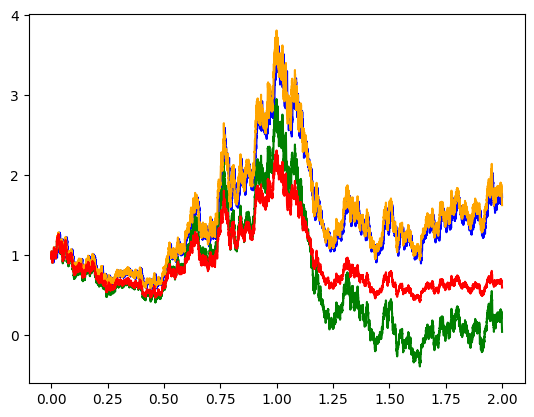

In [105]:
plt.plot(lead_lag_sol.ts, lead_lag_sol.ys[:,0], color = "blue")
plt.plot(lead_lag_sol.ts, lead_lag_sol.ys[:,1], color = "green")
plt.plot(times, strat_true_array, color = "orange")
plt.plot(times, ito_true_array, color = "red")

In [ ]:
y0 = jnp.array([1, 1])
drift = lambda t, y, args: jnp.array([0, 0])
diffusion = lambda t, y, args: jnp.array([[y[0], 0], [0, y[0]]])
solver_epsilon = 0.001*epsilon
terms = MultiTerm(ODETerm(drift), ControlTerm(diffusion, lead_lag_control))
strat_solver = Midpoint()
saveat = SaveAt(ts = times)
lead_lag_sol = diffeqsolve(terms, strat_solver, t0, t1, dt0 = solver_epsilon, max_steps = None, y0 = y0, saveat=saveat)

def ito_sol_true(bm):
    return lambda t: jnp.exp(bm(t) - t/2)

def strat_sol_true(bm):
    return lambda t: jnp.exp(bm(t))

ito_true_array = fun_to_array(times, ito_sol_true(bm_control))
strat_true_array = fun_to_array(times, strat_sol_true(bm_control))